In [1]:
import os
import sys
import datetime as dt

import cartopy.crs as ccrs
import easygems.healpix as egh
import intake
import matplotlib.pyplot as plt
import numpy as np

# import healpy as hp
import xarray as xr

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
# Filter out annoying warning.
import warnings

# from utils import haversine, hp_mods, get_nn_lon_lat_index

warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

In [97]:
# Open catalog.
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
# sim = 'um_glm_n2560_RAL3p3_tuned_hk26'
sim = 'um_glm_n1280_GAL9_v2_hk26'
sim_cat = cat[sim]
ds = sim_cat(zoom=4, time='PT1H').to_dask().pipe(hp_mods)

In [71]:
ds.pr

<xarray.DataArray 'pr' (time: 9745, cell: 768)> Size: 30MB
dask.array<open_dataset-pr, shape=(9745, 768), dtype=float32, chunksize=(1024, 768), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 78kB 2020-01-20 ... 2021-03-01
    crs      int64 8B 0
  * cell     (cell) int64 6kB 0 1 2 3 4 5 6 7 ... 761 762 763 764 765 766 767
    lat      (cell) float64 6kB 4.78 9.594 9.594 14.48 ... -9.594 -9.594 -4.78
    lon      (cell) float64 6kB 45.0 50.62 39.38 45.0 ... 320.6 309.4 315.0
Attributes:
    standard_name:  precipitation_flux
    units:          kg m-2 s-1
    source:         Data from Met Office Unified Model
    um_version:     13.5
    STASH:          [1, 5, 205]
    cell_methods:   time: mean (interval: 1 hour)
    long_name:      precipitation_flux
    variable_id:    pr
    UM_vars:        ['convective_rainfall_flux', 'convective_snowfall_flux', ...
    notes:          Combined rain and snow, convective and stratiform. Hourly...
    grid_mapping:   crs

<Figure size 640x480 with 0 Axes>

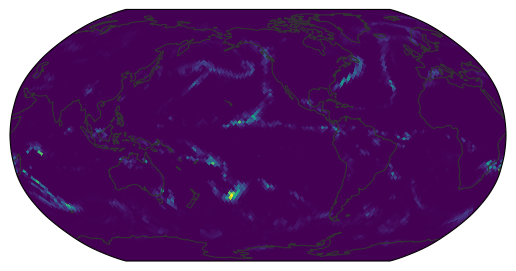

In [39]:
egh.healpix_show(ds.pr.isel(time=4))


## Onset Period analysis

Marcia's technique takes the following steps:
1. Butterworth filter precipitation timeseries with a 60-day window Pr_{60}
2. Take time derivative of Pr_{60}
3. Identify periods where Pr_{60} and dPr_{60}/dt are positive for 30 days or more.
4. ??? Refine onset ??? 

In [153]:
import OnsetPeriod_toolbox as optb

fwin = 60  # size of the butterworth filtering window
minlen = 30  # minimum length of the onset period envelope
pp = ds.pr.isel(cell=10).resample(time="1D").mean()


def onset_period(
    pp, deltat=None, max_dry_frac_rainfall=0.3, refine=False
):
    if deltat==None:
        deltat=pp.time.dt.dayofyear[0].item()
    # step 1
    flt = optb.butterworth(pp, fwin)

    # step 2
    grd = np.gradient(flt)

    # step 3
    rny = xr.where(((flt > 0) & (grd > 0)), 1, 0)
    fd, lns = optb.FindOnsetPeriods(rny, minlen)
    
    #### NOT SURE WHETHER TO REMOVE P1
    #remove first onset period if it starts at the very beginning of the sim
    if fd and fd[0] == 0:
        fd = fd[1:]
        lns = lns[1:]

    if refine:
        for ons_ix in range(len(fd)):
            this_pp = pp[fd[ons_ix] : fd[ons_ix] + lns[ons_ix]]
            fd[ons_ix], lns[ons_ix] = RefineOns(
                pp, pp.mean(dim="time") * max_dry_frac_rainfall
            )
    # shift back to day of year rather than day of simulation
    first_days = np.array(fd) + deltat
    last_days = np.array(fd) + np.array(lns) + deltat

    return first_days, last_days

KeyboardInterrupt: 

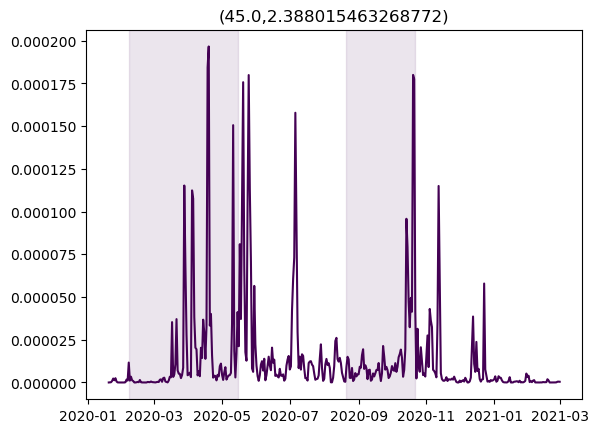

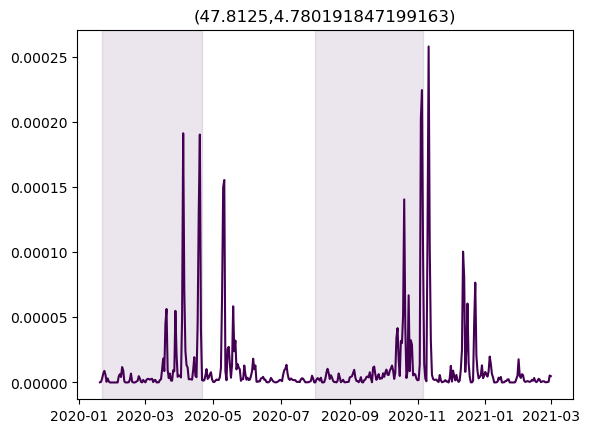

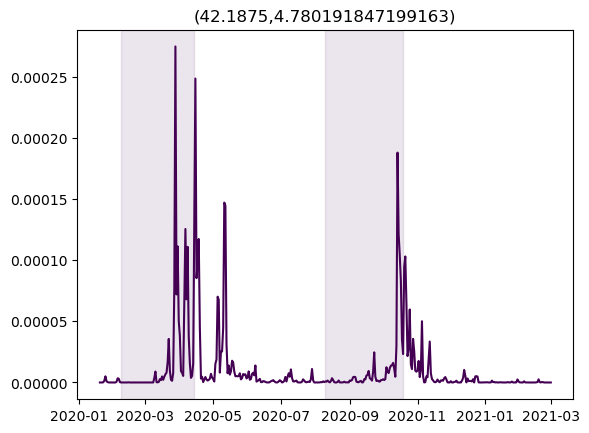

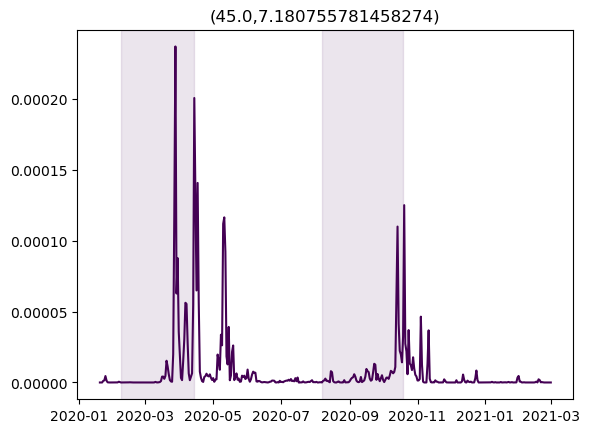

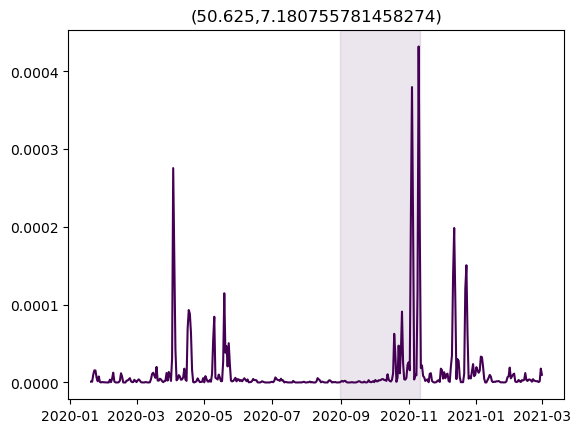

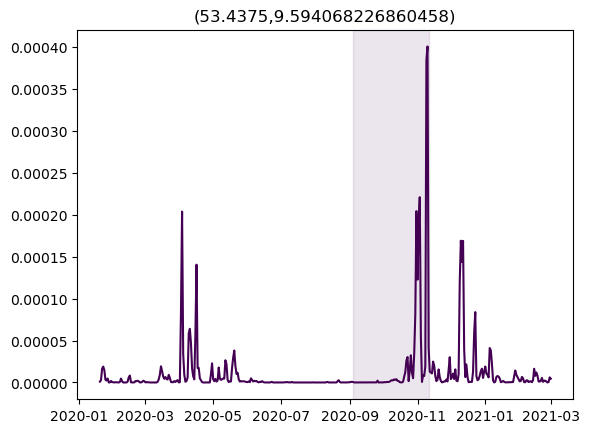

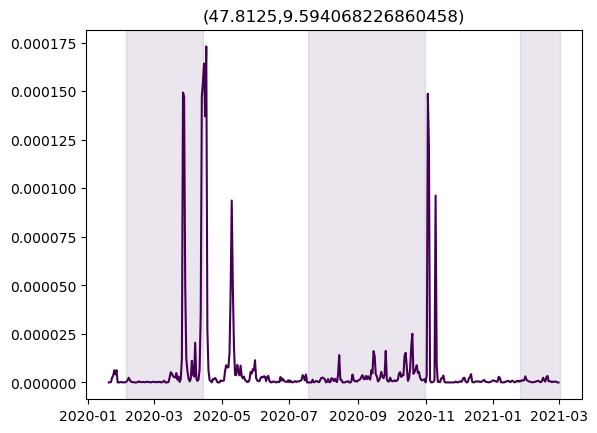

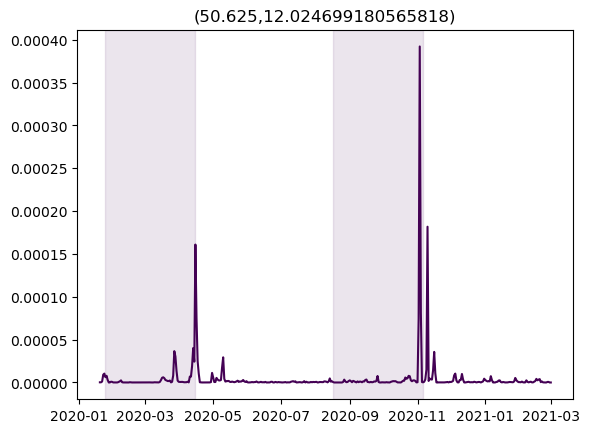

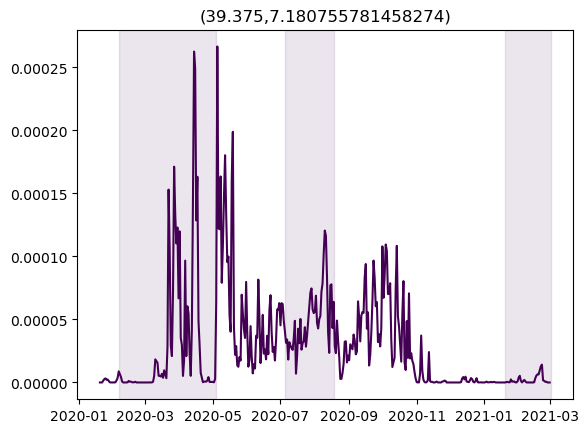

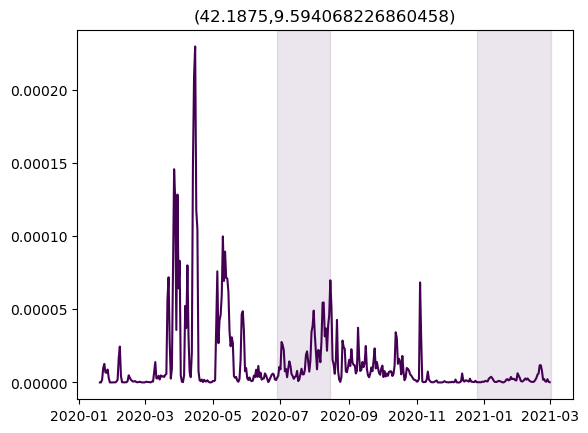

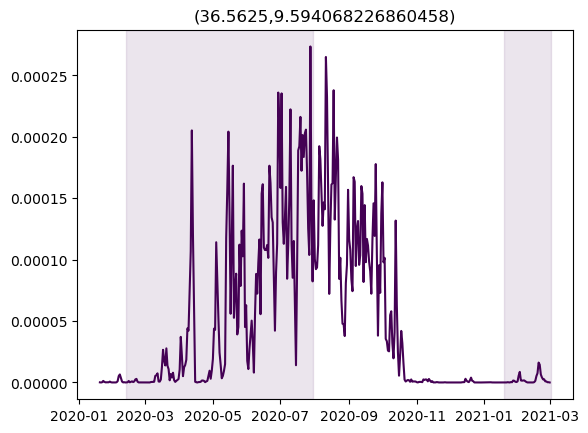

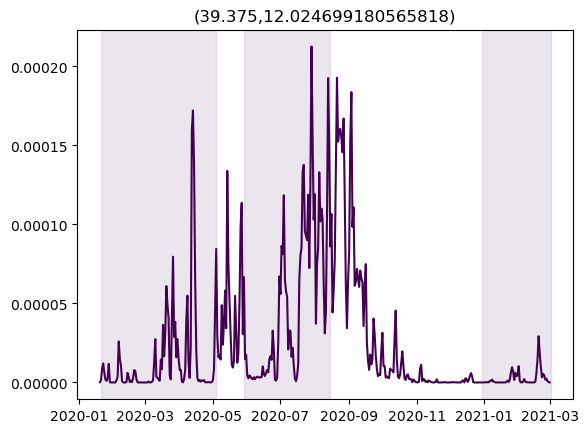

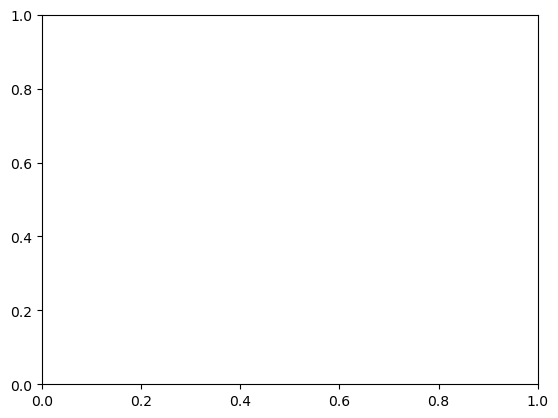

In [154]:
for cell_ix in range(len(ds.pr.cell[:20])):
    # cell_ix=493
    plt.figure()
    color=plt.cm.viridis(cell_ix/len(ds.pr.cell))
    pp = ds.pr.isel(cell=cell_ix).resample(time="1D").mean()
    fds, lds = onset_period_1d(pp,pp.time,refine=False)

    plt.plot(pp.time, pp, color=color)
    [
        plt.axvspan(
            dt.datetime(2020,1,1)+dt.timedelta(days=int(fds[ix])-1),
            dt.datetime(2020,1,1)+dt.timedelta(days=int(lds[ix])-1),
            alpha=0.1,
            color=color,
        ) 
        for ix in range(len(fds)) if int(fds[ix]==fds[ix])
    ]
    plt.title(f"({pp.lon.data},{pp.lat.data})")

In [155]:
def onset_period_1d(
    pp_1d,
    time,
    max_periods=5,
    max_dry_frac_rainfall=0.3,
    refine=False,
):
    """
    Apply onset_period to one grid-cell time series.

    Returns fixed-length arrays so xarray can combine outputs.
    """
    pp = xr.DataArray(
        pp_1d,
        dims=["time"],
        coords={"time": time},
    )

    deltat = int(pp.time.dt.dayofyear[0].item())

    first_days, last_days = onset_period(
        pp,
        deltat=deltat,
        max_dry_frac_rainfall=max_dry_frac_rainfall,
        refine=refine,
    )

    first_out = np.full(max_periods, np.nan)
    last_out = np.full(max_periods, np.nan)

    n = min(len(first_days), max_periods)
    first_out[:n] = first_days[:n]
    last_out[:n] = last_days[:n]

    return first_out, last_out

In [ ]:
sim = "um_glm_n1280_GAL9_v2_hk26"
# sim = "um_glm_n2560_RAL3p3_tuned_hk26"
max_periods = 2
zooms = [3, 4, 5]
labels = ["(a)","(b)","(c)","(d)","(e)","(f)"]
projection = ccrs.PlateCarree()

for sim in ["um_glm_n1280_GAL9_v2_hk26","um_glm_n2560_RAL3p3_tuned_hk26"]:
    sim_cat = cat[sim]
    fig, axes = plt.subplots(
        len(zooms),
        2,
        figsize=(10, 8),
        subplot_kw={"projection": projection},
        layout="constrained",
    )
    label_ix=0
    for zoom_ix, zoom in enumerate(zooms):
        ds = sim_cat(zoom=zoom, time="PT1H").to_dask().pipe(hp_mods)
    
        pp_all = ds.pr.resample(time="1D").mean().chunk(dict(time=-1))
        first_days, last_days = xr.apply_ufunc(
            onset_period_1d,
            pp_all,
            pp_all["time"],
            input_core_dims=[["time"], ["time"]],
            output_core_dims=[["period"], ["period"]],
            kwargs={
                "max_periods": max_periods,
                "max_dry_frac_rainfall": 0.1,
                "refine": False,
            },
            vectorize=True,
            dask="parallelized",
            output_dtypes=[float, float],
            dask_gufunc_kwargs={
                "output_sizes": {"period": max_periods},
            },
        )
    
        first_days = first_days.assign_coords(period=np.arange(max_periods))
        last_days = last_days.assign_coords(period=np.arange(max_periods))
    
        for ix in range(max_periods):
            label=labels[label_ix]
            ax = axes[zoom_ix, ix]
            ax.set_global()
            ax.coastlines()
            im = egh.healpix_show(
                first_days.sel(period=ix) % 365, ax=ax, vmin=0, vmax=365, cmap="hsv"
            )
    
            ax.set_title(f"{label} zoom={zoom}")
            label_ix+=1
    
    fig.suptitle(sim)
    plt.colorbar(im)